In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')

In [3]:
xgb_clf = XGBClassifier(n_estimators=300, max_depth=7, learning_rate=0.1, random_state=20, eval_metric='logloss')
cat_clf = CatBoostClassifier(n_estimators=100, random_state=20, verbose=0)
rf_clf  = RandomForestClassifier(n_estimators=200, random_state=20)

In [4]:
voting_model_pre = VotingClassifier(
    estimators=[
        ('xgb', xgb_clf),
        ('cat', cat_clf),
        ('rf', rf_clf)
    ],
    voting='soft'
)

voting_model_pre.fit(x_train_pre, y_train_pre)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_con...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('cat',
                              CatBoostClassifier(n_estimators=100, random_state=20, verbose=0)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=20))],
                 voting='soft')

In [5]:
voting_pred_pre = voting_model_pre.predict(x_test_pre)
voting_prob_pre = voting_model_pre.predict_proba(x_test_pre)[:, 1]
print(voting_prob_pre)

[0.91003014 0.59461799 0.70382434 0.39697502 0.95403461 0.18350504
 0.44626325 0.97344299 0.77572295 0.73873146 0.29092417 0.70520676
 0.86516196 0.86699089 0.52548593 0.95483302 0.98537392 0.70762305
 0.84404149 0.68857195 0.11473899 0.06472588 0.03318323 0.0439395
 0.10566308 0.22806407 0.45914175 0.93010173 0.90877643 0.80957534
 0.0993225  0.07229074 0.06855605 0.21189359 0.88046535 0.96639653
 0.31004507 0.17461695 0.1560927  0.32101094 0.14799467 0.32201721
 0.10356148 0.8156576  0.43066747 0.83593836 0.7558199  0.25221966
 0.446428   0.22676938 0.24459901 0.86011875 0.94103463 0.93477112
 0.92228594 0.25462949 0.51711989 0.7099717  0.4019263  0.23005392
 0.13769824 0.92809646 0.16164602 0.27060108 0.22869594 0.67360918
 0.788675   0.20738856 0.15125811 0.8015601  0.09791103 0.97207446
 0.28692737 0.59965788 0.94640911 0.94977887 0.94064867 0.52109928
 0.82400915 0.89309706 0.80671446 0.10655577 0.18888578 0.33850794
 0.05748912 0.8111792  0.53911455 0.80417894 0.99169788 0.94424

In [6]:
voting_accuracy_pre = accuracy_score(y_test_pre, voting_pred_pre)
print("Voting Classifier Accuracy (Pre-split SMOTE):", round(voting_accuracy_pre, 4))


Voting Classifier Accuracy (Pre-split SMOTE): 0.9308


In [7]:
print(classification_report(y_test_pre, voting_pred_pre))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       339
           1       0.92      0.94      0.93       340

    accuracy                           0.93       679
   macro avg       0.93      0.93      0.93       679
weighted avg       0.93      0.93      0.93       679



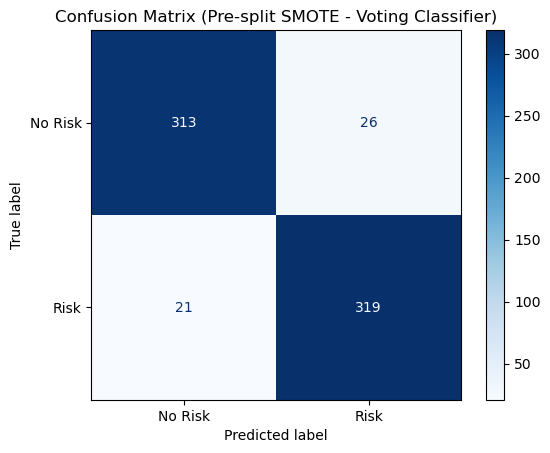

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, voting_pred_pre,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - Voting Classifier)")
plt.show()

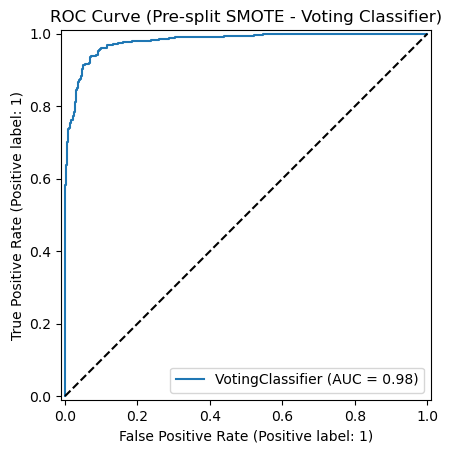

ROC-AUC Score: 0.9797


In [9]:
RocCurveDisplay.from_estimator(voting_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - Voting Classifier)')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, voting_prob_pre).round(4))


In [10]:
train_pred_pre = voting_model_pre.predict(x_train_pre)
train_accuracy_pre = accuracy_score(y_train_pre, train_pred_pre)
print("Train Accuracy:", round(train_accuracy_pre, 4))
print("Test Accuracy :", round(voting_accuracy_pre, 4))

Train Accuracy: 1.0
Test Accuracy : 0.9308


In [11]:
precision_pre = precision_score(y_test_pre, voting_pred_pre)
recall_pre    = recall_score(y_test_pre, voting_pred_pre)
f1_pre        = f1_score(y_test_pre, voting_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))

Precision: 0.9246
Recall   : 0.9382
F1 Score : 0.9314


In [12]:
cv_scores_pre = cross_val_score(voting_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))


CV ROC-AUC Scores: [0.9723 0.971  0.9604 0.9791 0.9717]
Mean: 0.9709 | Std dev: 0.006


In [13]:
joblib.dump(voting_model_pre, 'voting_model_presplit_smote.pkl')
print("Model saved.")

Model saved.


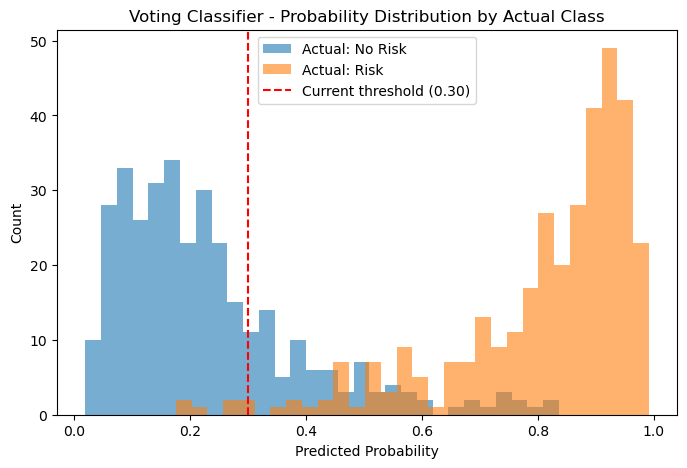

In [16]:
import matplotlib.pyplot as plt
import joblib

voting_model_pre = joblib.load('voting_model_presplit_smote.pkl')
x_test_pre = joblib.load('x_test_presplit_smote.pkl')
y_test_pre = joblib.load('y_test_presplit_smote.pkl')

voting_prob_pre = voting_model_pre.predict_proba(x_test_pre)[:, 1]

plt.figure(figsize=(8,5))
plt.hist(voting_prob_pre[y_test_pre==0], bins=30, alpha=0.6, label='Actual: No Risk')
plt.hist(voting_prob_pre[y_test_pre==1], bins=30, alpha=0.6, label='Actual: Risk')
plt.axvline(0.30, color='red', linestyle='--', label='Current threshold (0.30)')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()
plt.title('Voting Classifier - Probability Distribution by Actual Class')
plt.show()

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<10}{'Precision':<12}{'Recall':<10}{'F1':<10}")
for t in thresholds:
    preds_at_t = (voting_prob_pre >= t).astype(int)
    p = precision_score(y_test_pre, preds_at_t)
    r = recall_score(y_test_pre, preds_at_t)
    f1 = f1_score(y_test_pre, preds_at_t)
    print(f"{t:<10}{p:<12.4f}{r:<10.4f}{f1:<10.4f}")

Threshold Precision   Recall    F1        
0.2       0.6774      0.9941    0.8057    
0.3       0.8048      0.9824    0.8848    
0.4       0.8777      0.9706    0.9218    
0.5       0.9246      0.9382    0.9314    
0.6       0.9578      0.8676    0.9105    
0.7       0.9650      0.8118    0.8818    


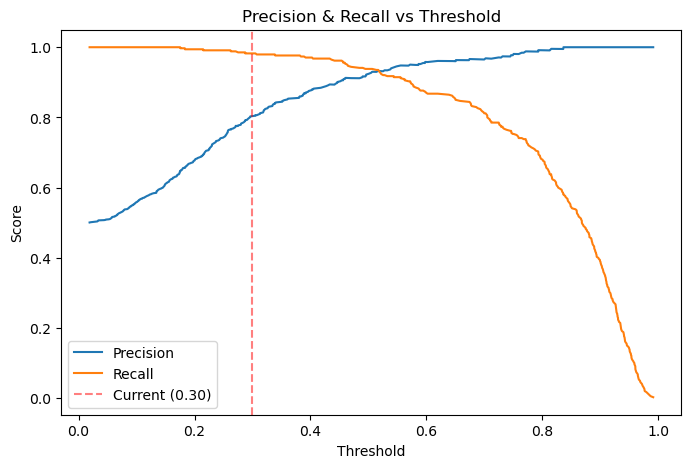

In [18]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test_pre, voting_prob_pre)

plt.figure(figsize=(8,5))
plt.plot(pr_thresholds, precisions[:-1], label='Precision')
plt.plot(pr_thresholds, recalls[:-1], label='Recall')
plt.axvline(0.30, color='red', linestyle='--', alpha=0.5, label='Current (0.30)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision & Recall vs Threshold')
plt.show()